# Astr 324, Spring 2026, University of Washington

# Week 10: Unsupervised Classification (Clustering) and Supervised Classification

#### This notebook is available from [github](https://github.com/uw-astr-324/astr-324-s26/blob/main/lectures/Week10.ipynb).

<a id='toc'></a>
## This notebook includes:

### Unsupervised Classification (Clustering) 

[Introduction to Clustering](#intro)
- unsupervised vs. supervised classification
- 1-D hypothesis testing        

[K-means clustering algorithm](#kmeans)

[Clustering with Gaussian Mixture models (GMM)](#gmm)

[Hierarchical clustering algorithm](#hca)


 
### Supervised Classification 

[Introduction to Supervised Classification](#intro2)
- supervised vs. unsupervised classification
- types of classifiers: generative vs. discriminative
- classification loss
- ROC curves 

[An example of a discriminative classifier: Support Vector Machine classifier](#svm)

[An example of a generative classifier: star/galaxy separation using Gaussian Naive Bayes classifier](#GNBsg)

[Comparison of many methods using ROC curves](#roc)



## Introduction to Clustering <a id='intro'></a>
[Go to top](#toc)

### Clustering

“Clustering” in machine learning context refers to a number of different aspects of data analysis. Given a multivariate point data set, we can ask whether it displays any structure, that is, concentrations of points. Alternatively, when a density estimate is available (see Week 9 lecture), we can search for “overdensities”. Another way to interpret clustering is to seek a partitioning or segmentation of data into smaller parts according to some criteria. 


Here is an illustration of clustering in 2-D space (see Lecture 7 for details):

![](figures/2Dclustering.png)

### Unsupervised vs. Supervised Classification  

In density estimation, we estimate joint probability distributions from multivariate data sets to identify the inherent clustering. This is essentially **unsupervised classification**. Here “unsupervised” means that there is no prior information about the number and properties of clusters.
In other words, this method is search for unknown structure in your (multi-dimensional) dataset.

If we have labels for some of these data points (e.g., an object is tall, short, red, or blue), we can develop a relationship between the label and the properties of a source. This is **supervised classification**. In other words, this method is finding objects in 
your (multi-dimensional) dataset that "look like" objects in your training set. 

Classification, regression, and density estimation are all closely related. For example, the regression function $\hat{y} = f(y|\vec{x})$ is the best estimated value of $y$ given a value of $\vec{x}$. In classification $y$ is categorical and $f(y|\vec{x})$ is called the _discriminant function_
 

##  1-D hypothesis testing
[Go to top](#toc)

How do we decide about the existance of a cluster? Let's start with
the simplest but fundamental example: 1-D hypothesis testing.


### **Motivating question:** 

You just measured x = 3, with a negligible measurement error.

You know that you could have drawn this value from one of two possible populations (e.g. stars and galaxies). One population can be described as N(0,2), and the other one as N(4,1). 

Which population is more likely, given your x?  

###  Naive (wrong) answer: 

3 is closer to 4 (1 "sigma away") than to 0
(1.5 "sigma away") so the second population, N(4,1), is more likely.

#### Let's see why this answer is wrong...
 

![](figures/1Dht.png) 

![](figures/1Dht2.png) 

![](figures/1Dht3.png) 

![](figures/1Dht4.png) 

## K-means clustering algorithm <a id='kmeans'></a>


![](figures/Kmeans.png) 

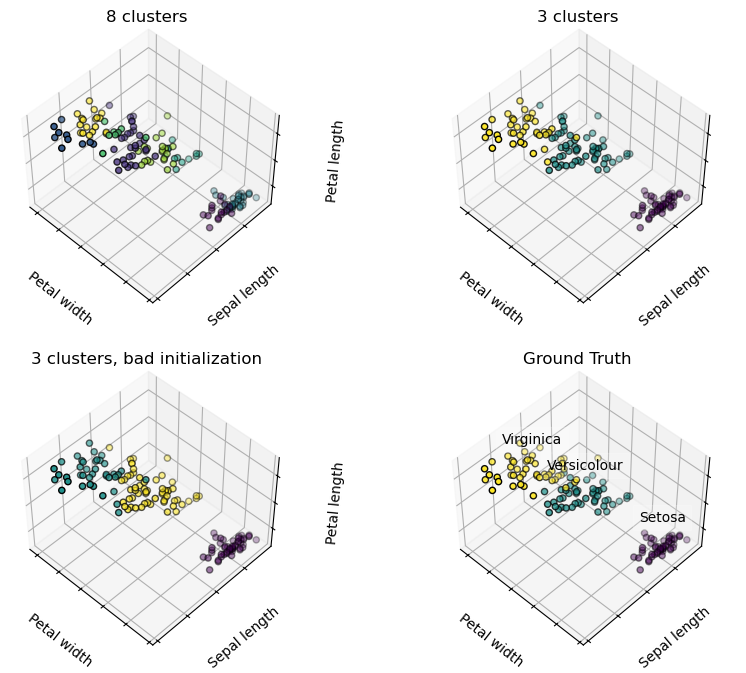

In [1]:
# Code source: Gaël Varoquaux
# Modified for documentation by Jaques Grobler
# License: BSD 3 clause
# see
# https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_iris.html

import matplotlib.pyplot as plt

# Though the following import is not directly being used, it is required
# for 3D projection to work with matplotlib < 3.2
import mpl_toolkits.mplot3d  # noqa: F401
import numpy as np

from sklearn import datasets
from sklearn.cluster import KMeans

np.random.seed(5)

iris = datasets.load_iris()
X = iris.data
y = iris.target

estimators = [
    ("k_means_iris_8", KMeans(n_clusters=8)),
    ("k_means_iris_3", KMeans(n_clusters=3)),
    ("k_means_iris_bad_init", KMeans(n_clusters=3, n_init=1, init="random")),
]

fig = plt.figure(figsize=(10, 8))
titles = ["8 clusters", "3 clusters", "3 clusters, bad initialization"]
for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)
    est.fit(X)
    labels = est.labels_

    ax.scatter(X[:, 3], X[:, 0], X[:, 2], c=labels.astype(float), edgecolor="k")

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel("Petal width")
    ax.set_ylabel("Sepal length")
    ax.set_zlabel("Petal length")
    ax.set_title(title)

# Plot the ground truth
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

for name, label in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax.text3D(
        X[y == label, 3].mean(),
        X[y == label, 0].mean(),
        X[y == label, 2].mean() + 2,
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )

ax.scatter(X[:, 3], X[:, 0], X[:, 2], c=y, edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Petal width")
ax.set_ylabel("Sepal length")
ax.set_zlabel("Petal length")
ax.set_title("Ground Truth")

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()

![](figures/Kmeans2.png) 

## There are many clustering methods! 
### see https://scikit-learn.org/stable/auto_examples/cluster/plot_cluster_comparison.html

![](figures/ClusteringMethods.png) 

## Clustering with Gaussian Mixture models (GMM) <a id='gmm'></a>
[Go to top](#toc)

We already addressed Gaussian Mixture models in Lecture 7 about Density Estimation.

If the clusters can be, at least approximately, described as multi-variate Gaussians, then GMM can be very powerful clustering tool.

Let's first introduce hierarchical clustering algorithm and then we'll compare their
performance on a real data set.


## Hierarchical clustering algorithm <a id='hca'></a>
[Go to top](#toc)

![](figures/hc1.png) 

![](figures/hc2.png) 


### Let's now apply this method to a real dataset: clustering of asteroids in the space of orbital elements



## Clustering of orbital data for asteroids

Asteroids are clustered in orbital parameter space (6 dimensions
but here we will consider two: semi-major axis and inclination)
and these clusters, known as families, are believed to be remnants of larger asteroids destroyed in collisions. Typically, families have
uniform colors, for more details see [Parker et al. 2008.](
http://faculty.washington.edu/ivezic/Publications/parker.pdf)

Using the Parker et al. dataset, available from astroML, we will apply 
Gaussian Mixture Model and the Minimum Spanning Tree model and
compare their clustering results.



### For completeness, we expect structure like this:

![Parker et al. asteroid families](http://faculty.washington.edu/ivezic/sdssmoc/MOC4_population_labels.jpg) 

In [2]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt
from sklearn.mixture import GaussianMixture as GMM
from sklearn.neighbors import KernelDensity

from astroML.clustering import HierarchicalClustering, get_graph_segments
from astroML.datasets import fetch_moving_objects

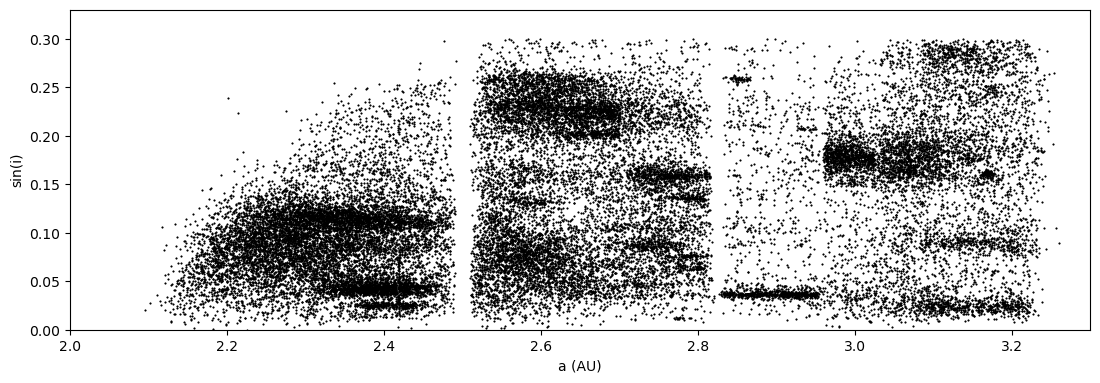

In [3]:
# Fetch data and extract the desired quantities
dataAll = fetch_moving_objects(Parker2008_cuts=True)
data = dataAll[1:]
a = data['aprime']
sini = data['sin_iprime']
acolor = data['mag_a']
izcolor = data['mag_i'] - data['mag_z']
X = np.vstack([a, sini]).T

#------------------------------------------------------------
# Plot 
xmin, xmax = (2.0, 3.3)
ymin, ymax = (0.0, 0.33)
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(hspace=0, left=0.1, right=0.95, bottom=0.1, top=0.9)

ax = fig.add_subplot(311)
ax.scatter(X[:, 0], X[:, 1], s=1, lw=0.5, c='k')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('a (AU)')
ax.set_ylabel('sin(i)')

plt.show()

In [4]:
#------------------------------------------------------------
# Compute GMM models & AIC/BIC for up to 59 clusters
N = np.arange(1, 60)
def compute_GMM(N, covariance_type='full', max_iter=100):
    models = [None for n in N]
    for i in range(len(N)):
        models[i] = GMM(n_components=N[i], max_iter=max_iter,
                        covariance_type=covariance_type)
        models[i].fit(X)
    return models

models = compute_GMM(N)
AIC = [m.aic(X) for m in models]
BIC = [m.bic(X) for m in models]
i_best = np.argmin(BIC)
gmm_best = models[i_best]

print("best fit converged:", gmm_best.converged_)
print("BIC: n_components =  %i" % N[i_best])

best fit converged: True
BIC: n_components =  41


In [5]:
# replaces draw_ellipse from astroML.plotting.tools 
from matplotlib.patches import Ellipse
def draw_ellipse(mu, C, scales=[1, 2, 3], ax=None, **kwargs):
    if ax is None:
        ax = plt.gca()

    # find principal components and rotation angle of ellipse
    sigma_x2 = C[0, 0]
    sigma_y2 = C[1, 1]
    sigma_xy = C[0, 1]

    alpha = 0.5 * np.arctan2(2 * sigma_xy,
                             (sigma_x2 - sigma_y2))
    tmp1 = 0.5 * (sigma_x2 + sigma_y2)
    tmp2 = np.sqrt(0.25 * (sigma_x2 - sigma_y2) ** 2 + sigma_xy ** 2)

    sigma1 = np.sqrt(tmp1 + tmp2)
    sigma2 = np.sqrt(tmp1 - tmp2)

    for scale in scales:
        ax.add_patch(Ellipse((mu[0], mu[1]),
                             2 * scale * sigma1, 2 * scale * sigma2,
                             angle = alpha * 180. / np.pi,
                             **kwargs))

showing the best 41 clusters
0 23 0.04336545855999267
1 13 0.04322417407789611
2 9 0.04081207531047035
3 3 0.03959774998975658
4 8 0.03815738031807873
5 31 0.037834097251262105
6 15 0.03721440606300079
7 1 0.03684388992403028
8 37 0.03678126847883795
9 32 0.0339113131285494
10 4 0.03187233853174164
11 26 0.03186788374479226
12 30 0.030216536077221953
13 28 0.0301947974372556
14 29 0.030027465004769667
15 2 0.027996773265185855
16 38 0.02762213685230951
17 22 0.02670134362304897
18 6 0.025115066320402626
19 18 0.02203312091050051
20 40 0.021699291549850945
21 14 0.02109401226962826
22 19 0.020254762419111966
23 39 0.020077599271459246
24 16 0.019696537318302645
25 11 0.01886470807435177
26 21 0.018843537174452335
27 27 0.018131642968197526
28 12 0.016839521596278367
29 17 0.016739231378679387
30 25 0.016256796683022445
31 10 0.015907724688747297
32 36 0.015881765814135956
33 20 0.01404981924775767
34 5 0.013926041386575999
35 35 0.01363898671089415
36 34 0.013408678325053873
37 7 0.0121

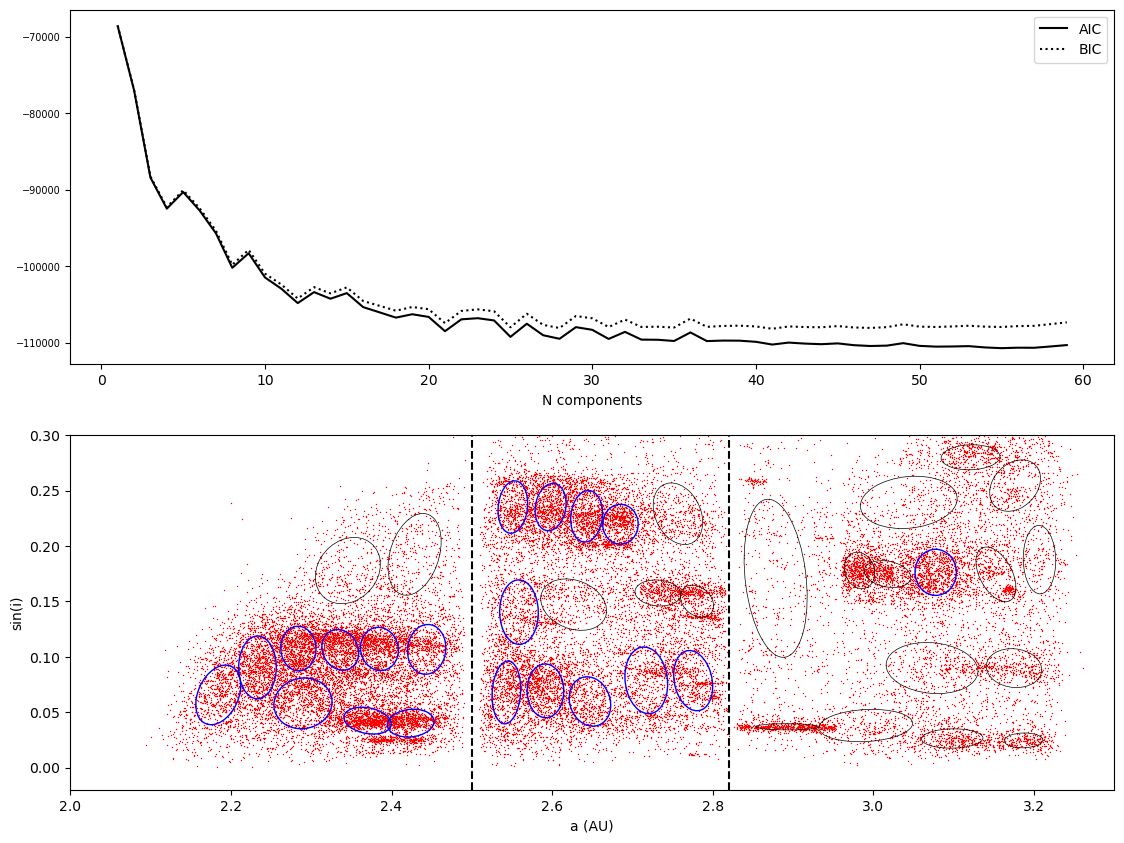

In [6]:
#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(wspace=0.45, bottom=0.25, top=0.9, left=0.1, right=0.97)

print('showing the best', N[i_best], 'clusters')

# plot AIC/BIC
ax = fig.add_subplot(211)
ax.plot(N, AIC, '-k', label='AIC')
ax.plot(N, BIC, ':k', label='BIC')
ax.legend(loc=1)
ax.set_xlabel('N components')
plt.setp(ax.get_yticklabels(), fontsize=7)

# plot best configurations for AIC and BIC
ax = fig.add_subplot(212)

ax.scatter(a, sini, c='red', s=1, lw=0)

ind = np.argsort(gmm_best.weights_)[::-1]
for cnt, i in enumerate(ind[:N[i_best]]):
    mu = gmm_best.means_[i]
    C = gmm_best.covariances_[i]
    w = gmm_best.weights_[i]
    print(cnt, i, w)
    # the 20 most numerous clusters in blue
    if (cnt<20):
        draw_ellipse(mu, C, scales=[1.0], ax=ax, fc='none', lw=1.0, ec='blue')
    else:
        draw_ellipse(mu, C, scales=[1.0], ax=ax, fc='none', lw=0.5, ec='k')
 
ax.plot([2.5, 2.5], [-0.02, 0.3], '--k')
ax.plot([2.82, 2.82], [-0.02, 0.3], '--k')

ax.set_xlim(2.0, 3.3)
ax.set_ylim(-0.02, 0.3)

ax.set_xlabel('a (AU)')
ax.set_ylabel('sin(i)')

plt.show()

## What can we conclude about these GMM results?


## Let's now use the Minimum Spanning Tree clustering model

In [7]:
#------------------------------------------------------------
# Compute the Minimum Spanning Tree clustering model
n_neighbors = 10
edge_cutoff = 0.9
cluster_cutoff = 10
model = HierarchicalClustering(n_neighbors=10, edge_cutoff=edge_cutoff,
                               min_cluster_size=cluster_cutoff)
model.fit(X)
n_components = model.n_components_
labels = model.labels_
#------------------------------------------------------------
# Get the x, y coordinates of the beginning and end of each line segment
T_x, T_y = get_graph_segments(model.X_train_,
                              model.full_tree_)
T_trunc_x, T_trunc_y = get_graph_segments(model.X_train_,
                                          model.cluster_graph_)

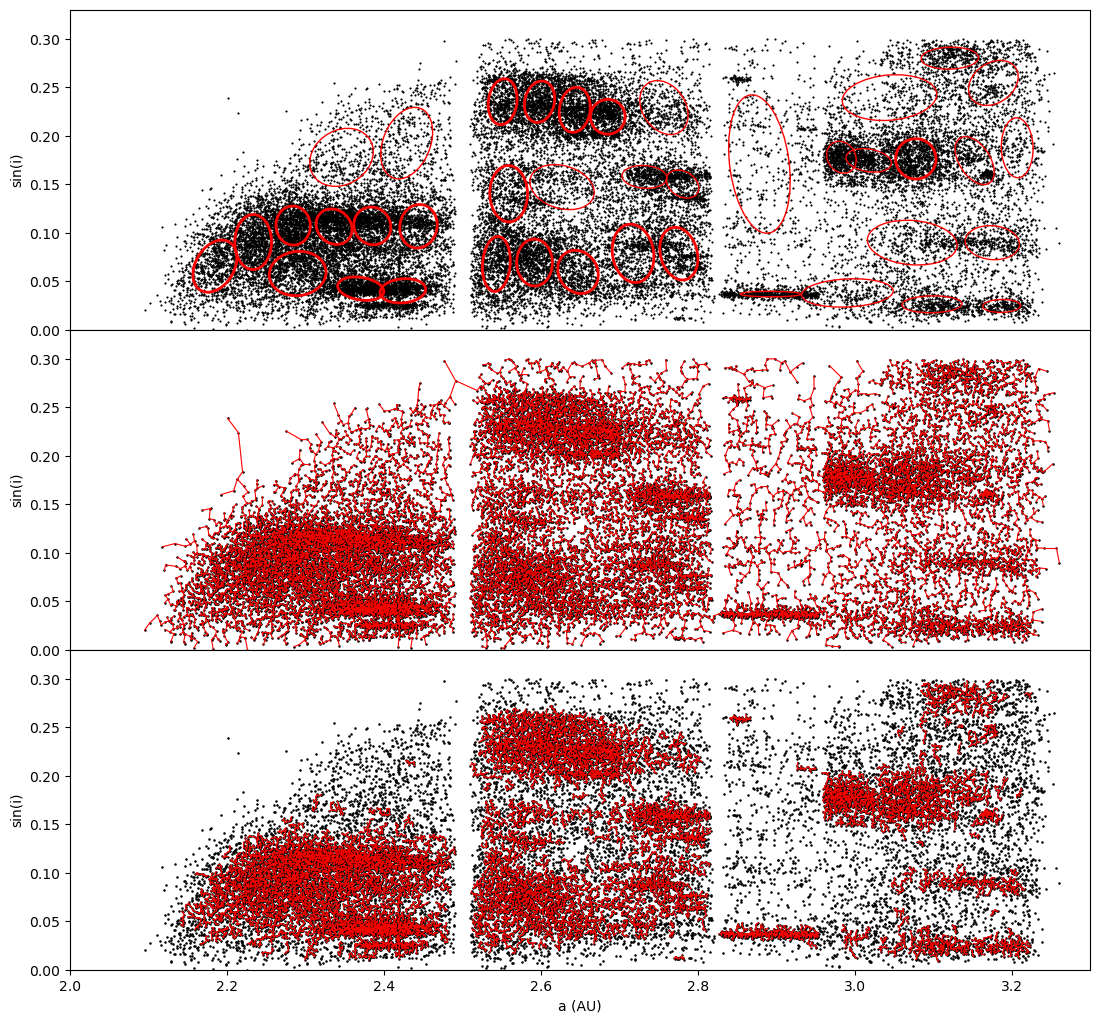

In [8]:
#------------------------------------------------------------
# Plot the results
xmin, xmax = (2.0, 3.3)
ymin, ymax = (0.0, 0.33)
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(hspace=0, left=0.1, right=0.95, bottom=0.1, top=0.9)

ax = fig.add_subplot(311)
ax.scatter(X[:, 0], X[:, 1], s=1, lw=0.5, c='k')
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.xaxis.set_major_formatter(plt.NullFormatter())
ax.set_ylabel('sin(i)')
# GMM comparison
for cnt, i in enumerate(ind[:N[i_best]]):
    mu = gmm_best.means_[i]
    C = gmm_best.covariances_[i]
    w = gmm_best.weights_[i]
    # the 20 most numerous clusters in blue
    if (cnt<20):
        draw_ellipse(mu, C, scales=[1.0], ax=ax, fc='none', lw=2.0, ec='red')
    else:
        draw_ellipse(mu, C, scales=[1.0], ax=ax, fc='none', lw=1.0, ec='red')

ax = fig.add_subplot(312)
ax.scatter(X[:, 0], X[:, 1], s=1, lw=0.8, c='k')
ax.plot(T_x, T_y, c='red', lw=0.8)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.xaxis.set_major_formatter(plt.NullFormatter())
ax.set_ylabel('sin(i)')

ax = fig.add_subplot(313)
ax.scatter(X[:, 0], X[:, 1], s=1, lw=0.8, c='k')
ax.plot(T_trunc_x, T_trunc_y, c='red', lw=0.8)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel('a (AU)')
ax.set_ylabel('sin(i)')
        
plt.show()

### What do you conclude about these results? How do they compare to GMM results? 

#### Note: we could now, on per object basis, compare the two classifications into background and clustered objects and somehow (depending on application) combine them into the final classification. 


## Let's do kernel density estimate for completeness

In [9]:
# Fetch data (again) and extract the desired quantities
dataAll = fetch_moving_objects(Parker2008_cuts=True)
data = dataAll[1:]
a = data['aprime']
sini = data['sin_iprime']
acolor = data['mag_a']
izcolor = data['mag_i'] - data['mag_z']
X = np.vstack([a, sini]).T

In [10]:
# Create the grid on which to evaluate the results
Nx = 200
Ny = 100
xmin, xmax = (2.0, 3.3)
ymin, ymax = (0, 0.31)

#X, Y = np.meshgrid(
#    np.linspace(xmin, xmax, Nx),
#    np.linspace(ymin, ymax, Ny)
#)

#Xgrid = np.column_stack([X.ravel(), Y.ravel()])

Xgrid = np.vstack(
    list(
        map(
            np.ravel,
            np.meshgrid(
                np.linspace(xmin, xmax, Nx),
                np.linspace(ymin, ymax, Ny)
            )
        )
    )
).T


# evaluate Gaussian kernel
BW = 0.003
def estimate_kde(ker):
    kde = KernelDensity(bandwidth=BW, kernel='gaussian')
    log_dens = kde.fit(X).score_samples(Xgrid)
    dens = X.shape[0] * np.exp(log_dens).reshape((Ny, Nx))
    return dens
   
dens1 = estimate_kde('gaussian')

In [11]:
# ----------------------------------------------------------------------
# Original data
# X must have shape (Npoints, 2)

# Example:
# X = np.column_stack([xdata, ydata])

# ----------------------------------------------------------------------
# Create evaluation grid

Nx = 200
Ny = 100

xmin, xmax = (2.0, 3.3)
ymin, ymax = (0.0, 0.31)

xgrid = np.linspace(xmin, xmax, Nx)
ygrid = np.linspace(ymin, ymax, Ny)

Xg, Yg = np.meshgrid(xgrid, ygrid)

Xgrid = np.column_stack([
    Xg.ravel(),
    Yg.ravel()
])

# ----------------------------------------------------------------------
# KDE estimate

BW = 0.003

def estimate_kde(kernel='gaussian'):

    kde = KernelDensity(
        bandwidth=BW,
        kernel=kernel
    )

    kde.fit(X)

    log_dens = kde.score_samples(Xgrid)

    dens = np.exp(log_dens).reshape(Ny, Nx)

    return dens

dens1 = estimate_kde()

In [12]:
def plot_figure(data, norm='linear'):
    fig = plt.figure(figsize=(12,6))

    fig.subplots_adjust(
        hspace=0,
        left=0.1,
        right=0.95,
        bottom=0.1,
        top=0.9
    )

    ax = fig.add_subplot(111)

    ax.imshow(
        data,
        origin='lower',
        norm=norm,
        extent=(xmin, xmax, ymin, ymax),
        aspect='auto',
        cmap=plt.cm.jet
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    plt.show()

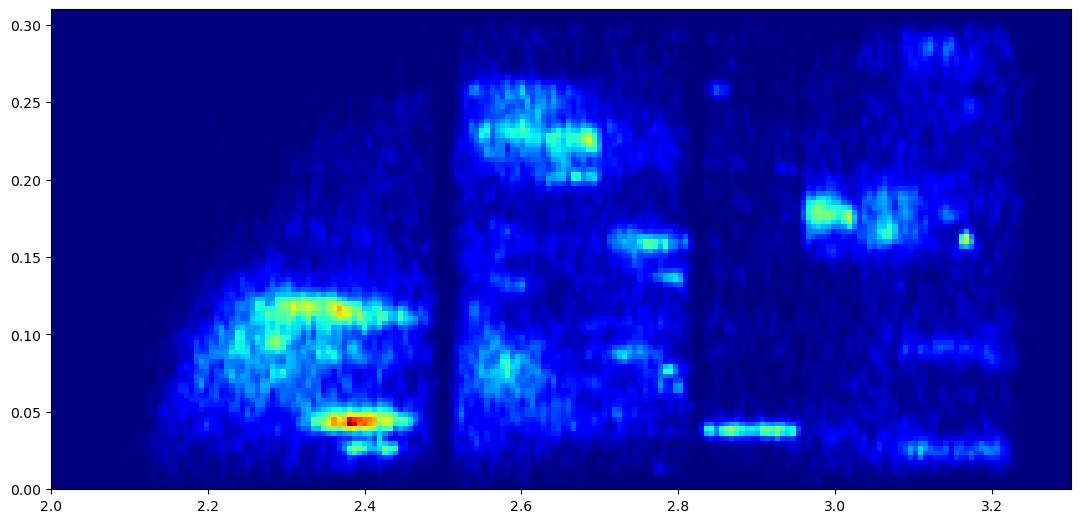

In [13]:
# plot kde map
plot_figure(dens1, norm='linear')

## What is the main downside of this method for finding clusters?


### Let's now try 
## DBSCAN: "Density-Based Spatial Clustering of Applications with Noise"

## OPTICS: "Ordering Points To Identify Clustering Structure"

### OPTICS should be better at finding clusters of varying density

### for a detailed discussion of OPTICS vs. DBSCAN, see
### https://www.atlantbh.com/clustering-algorithms-dbscan-vs-optics


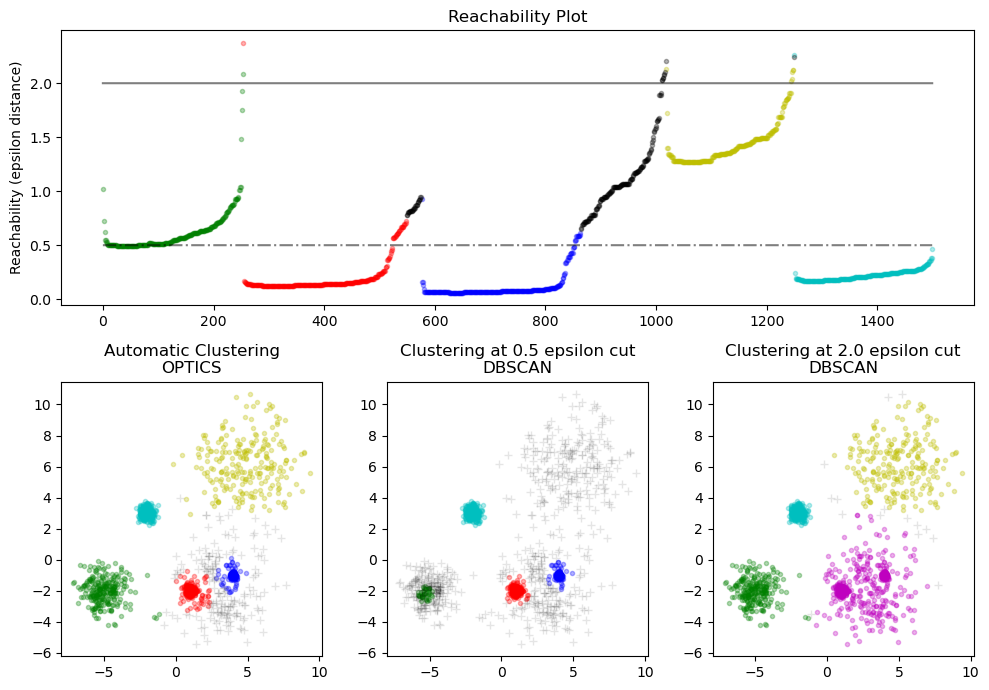

In [14]:
# Authors: Shane Grigsby <refuge@rocktalus.com>
#          Adrin Jalali <adrin.jalali@gmail.com>
# License: BSD 3 clause

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import OPTICS, cluster_optics_dbscan

# Generate sample data

np.random.seed(0)
n_points_per_cluster = 250

C1 = [-5, -2] + 0.8 * np.random.randn(n_points_per_cluster, 2)
C2 = [4, -1] + 0.1 * np.random.randn(n_points_per_cluster, 2)
C3 = [1, -2] + 0.2 * np.random.randn(n_points_per_cluster, 2)
C4 = [-2, 3] + 0.3 * np.random.randn(n_points_per_cluster, 2)
C5 = [3, -2] + 1.6 * np.random.randn(n_points_per_cluster, 2)
C6 = [5, 6] + 2 * np.random.randn(n_points_per_cluster, 2)
X = np.vstack((C1, C2, C3, C4, C5, C6))

clust = OPTICS(min_samples=50, xi=0.05, min_cluster_size=0.05)

# Run the fit
clust.fit(X)

labels_050 = cluster_optics_dbscan(
    reachability=clust.reachability_,
    core_distances=clust.core_distances_,
    ordering=clust.ordering_,
    eps=0.5,
)
labels_200 = cluster_optics_dbscan(
    reachability=clust.reachability_,
    core_distances=clust.core_distances_,
    ordering=clust.ordering_,
    eps=2,
)

space = np.arange(len(X))
reachability = clust.reachability_[clust.ordering_]
labels = clust.labels_[clust.ordering_]

plt.figure(figsize=(10, 7))
G = gridspec.GridSpec(2, 3)
ax1 = plt.subplot(G[0, :])
ax2 = plt.subplot(G[1, 0])
ax3 = plt.subplot(G[1, 1])
ax4 = plt.subplot(G[1, 2])

# Reachability plot
colors = ["g.", "r.", "b.", "y.", "c."]
for klass, color in zip(range(0, 5), colors):
    Xk = space[labels == klass]
    Rk = reachability[labels == klass]
    ax1.plot(Xk, Rk, color, alpha=0.3)
ax1.plot(space[labels == -1], reachability[labels == -1], "k.", alpha=0.3)
ax1.plot(space, np.full_like(space, 2.0, dtype=float), "k-", alpha=0.5)
ax1.plot(space, np.full_like(space, 0.5, dtype=float), "k-.", alpha=0.5)
ax1.set_ylabel("Reachability (epsilon distance)")
ax1.set_title("Reachability Plot")

# OPTICS
colors = ["g.", "r.", "b.", "y.", "c."]
for klass, color in zip(range(0, 5), colors):
    Xk = X[clust.labels_ == klass]
    ax2.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
ax2.plot(X[clust.labels_ == -1, 0], X[clust.labels_ == -1, 1], "k+", alpha=0.1)
ax2.set_title("Automatic Clustering\nOPTICS")

# DBSCAN at 0.5
colors = ["g.", "r.", "b.", "c."]
for klass, color in zip(range(0, 4), colors):
    Xk = X[labels_050 == klass]
    ax3.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
ax3.plot(X[labels_050 == -1, 0], X[labels_050 == -1, 1], "k+", alpha=0.1)
ax3.set_title("Clustering at 0.5 epsilon cut\nDBSCAN")

# DBSCAN at 2.
colors = ["g.", "m.", "y.", "c."]
for klass, color in zip(range(0, 4), colors):
    Xk = X[labels_200 == klass]
    ax4.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
ax4.plot(X[labels_200 == -1, 0], X[labels_200 == -1, 1], "k+", alpha=0.1)
ax4.set_title("Clustering at 2.0 epsilon cut\nDBSCAN")

plt.tight_layout()
plt.show()

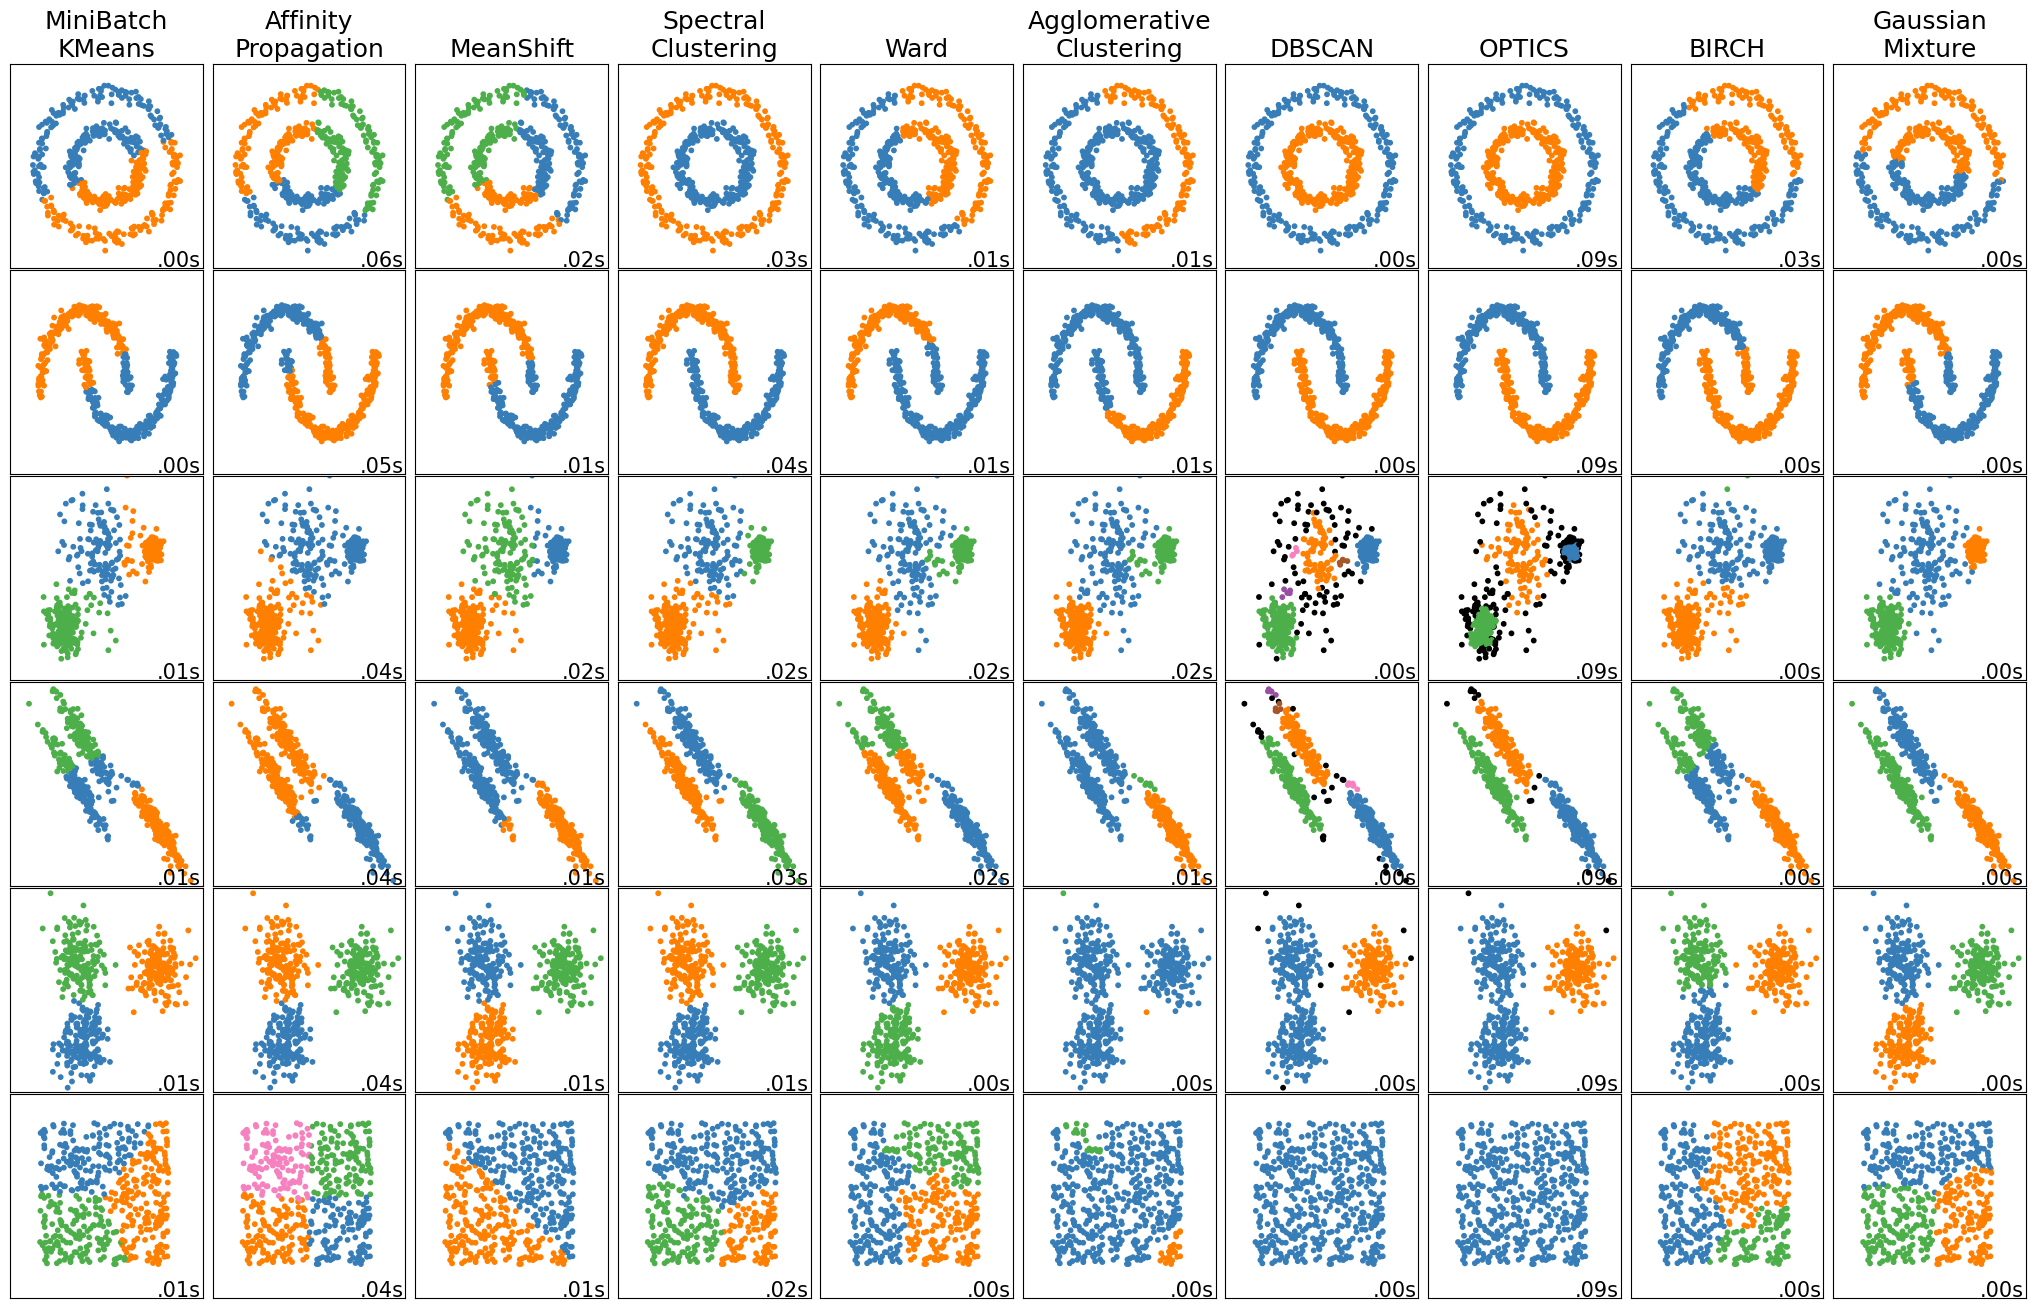

In [15]:
import time
import warnings
from itertools import cycle, islice

import matplotlib.pyplot as plt
import numpy as np

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 500
seed = 30
noisy_circles = datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=seed
)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=seed)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=seed)
rng = np.random.RandomState(seed)
no_structure = rng.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

# ============
# Set up cluster parameters
# ============
plt.figure(figsize=(9 * 2 + 3, 13))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.95, wspace=0.05, hspace=0.01
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 3,
    "n_clusters": 3,
    "min_samples": 7,
    "xi": 0.05,
    "min_cluster_size": 0.1,
    "allow_single_cluster": True,
    "hdbscan_min_cluster_size": 15,
    "hdbscan_min_samples": 3,
    "random_state": 42,
}

datasets = [
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 7,
            "xi": 0.08,
        },
    ),
    (
        noisy_moons,
        {
            "damping": 0.75,
            "preference": -220,
            "n_clusters": 2,
            "min_samples": 7,
            "xi": 0.1,
        },
    ),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 7,
            "xi": 0.01,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 7,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {"min_samples": 7, "xi": 0.1, "min_cluster_size": 0.2}),
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(datasets):
    # update parameters with dataset-specific values
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    # normalize dataset for easier parameter selection
    X = StandardScaler().fit_transform(X)

    # estimate bandwidth for mean shift
    bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])

    # connectivity matrix for structured Ward
    connectivity = kneighbors_graph(
        X, n_neighbors=params["n_neighbors"], include_self=False
    )
    # make connectivity symmetric
    connectivity = 0.5 * (connectivity + connectivity.T)

    # ============
    # Create cluster objects
    # ============
    ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)
    two_means = cluster.MiniBatchKMeans(
        n_clusters=params["n_clusters"],
        random_state=params["random_state"],
    )
    ward = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity
    )
    spectral = cluster.SpectralClustering(
        n_clusters=params["n_clusters"],
        eigen_solver="arpack",
        affinity="nearest_neighbors",
        random_state=params["random_state"],
    )
    dbscan = cluster.DBSCAN(eps=params["eps"])
    optics = cluster.OPTICS(
        min_samples=params["min_samples"],
        xi=params["xi"],
        min_cluster_size=params["min_cluster_size"],
    )
    affinity_propagation = cluster.AffinityPropagation(
        damping=params["damping"],
        preference=params["preference"],
        random_state=params["random_state"],
    )
    average_linkage = cluster.AgglomerativeClustering(
        linkage="average",
        n_clusters=params["n_clusters"],
        connectivity=connectivity,
    )
    birch = cluster.Birch(n_clusters=params["n_clusters"])
    gmm = mixture.GaussianMixture(
        n_components=params["n_clusters"],
        covariance_type="full",
        random_state=params["random_state"],
    )

    clustering_algorithms = (
        ("MiniBatch\nKMeans", two_means),
        ("Affinity\nPropagation", affinity_propagation),
        ("MeanShift", ms),
        ("Spectral\nClustering", spectral),
        ("Ward", ward),
        ("Agglomerative\nClustering", average_linkage),
        ("DBSCAN", dbscan),
        ("OPTICS", optics),
        ("BIRCH", birch),
        ("Gaussian\nMixture", gmm),
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        # catch warnings related to kneighbors_graph
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="the number of connected components of the "
                + "connectivity matrix is [0-9]{1,2}"
                + " > 1. Completing it to avoid stopping the tree early.",
                category=UserWarning,
            )
            warnings.filterwarnings(
                "ignore",
                message="Graph is not fully connected, spectral embedding"
                + " may not work as expected.",
                category=UserWarning,
            )
            algorithm.fit(X)

        t1 = time.time()
        if hasattr(algorithm, "labels_"):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        plt.subplot(len(datasets), len(clustering_algorithms), plot_num)
        if i_dataset == 0:
            plt.title(name, size=18)

        colors = np.array(
            list(
                islice(
                    cycle(
                        [
                            "#377eb8",
                            "#ff7f00",
                            "#4daf4a",
                            "#f781bf",
                            "#a65628",
                            "#984ea3",
                            "#999999",
                            "#e41a1c",
                            "#dede00",
                        ]
                    ),
                    int(max(y_pred) + 1),
                )
            )
        )
        # add black color for outliers (if any)
        colors = np.append(colors, ["#000000"])
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[y_pred])

        plt.xlim(-2.5, 2.5)
        plt.ylim(-2.5, 2.5)
        plt.xticks(())
        plt.yticks(())
        plt.text(
            0.99,
            0.01,
            ("%.2fs" % (t1 - t0)).lstrip("0"),
            transform=plt.gca().transAxes,
            size=15,
            horizontalalignment="right",
        )
        plot_num += 1

plt.show()


# Introduction to Supervised Classification <a id='intro2'></a>
[Go to top](#toc)

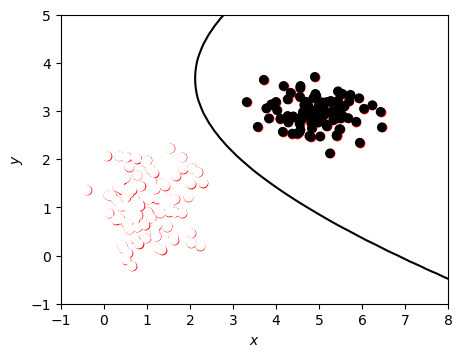

In [16]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook as Fig. 9.2
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import colors

from sklearn.naive_bayes import GaussianNB

#------------------------------------------------------------
# Simulate some data
np.random.seed(0)
mu1 = [1, 1]
cov1 = 0.3 * np.eye(2)

mu2 = [5, 3]
cov2 = np.eye(2) * np.array([0.4, 0.1])

X = np.concatenate([np.random.multivariate_normal(mu1, cov1, 100),
                    np.random.multivariate_normal(mu2, cov2, 100)])

# set labels for classification
y = np.zeros(200)
y[100:] = 1

#------------------------------------------------------------
### Fit the Naive Bayes classifier ###
clf = GaussianNB()
clf.fit(X, y)

# predict the classification probabilities on a grid
xlim = (-1, 8)
ylim = (-1, 5)
xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 71), np.linspace(ylim[0], ylim[1], 81))

Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z[:, 1].reshape(xx.shape)

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 3.75))
ax = fig.add_subplot(111)
ax.scatter(X[:, 0], X[:, 1], c='r', lw=1)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.binary)


# classification boundary 
ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$x$')
ax.set_ylabel('$y$')

plt.show()

## that was an easy 2-dimensional example; let's now see a 7-dimensional example

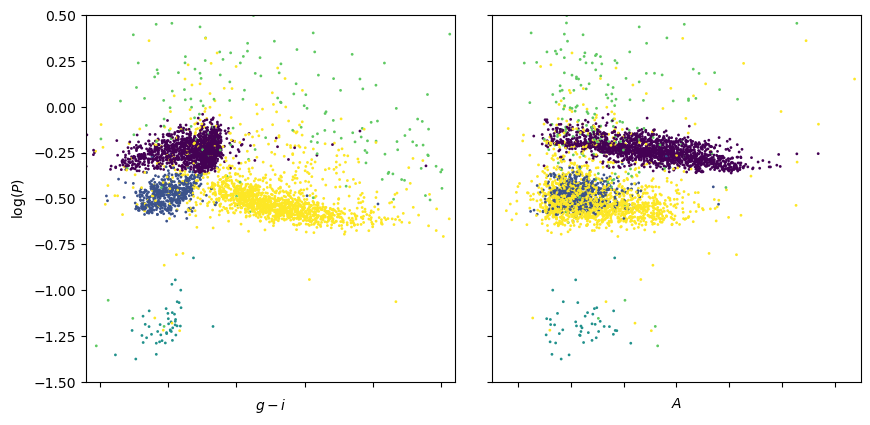

In [17]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from __future__ import print_function

import numpy as np
from matplotlib import pyplot as plt
from astroML.classification import GMMBayes
from sklearn.model_selection import train_test_split
from astroML.datasets import fetch_LINEAR_geneva

#----------------------------------------------------------------------
# use astroML to get LINEAR data
data = fetch_LINEAR_geneva()

# data array contains these quantities: 
attributes = [('gi', 'logP', 'ug', 'iK', 'JK', 'Ampl', 'skew')]
labels = ['$u-g$', '$g-i$', '$i-K$', '$J-K$',
          r'$\log(P)$', 'amplitude', 'skew']
cls = 'LCtype'
Ntrain = 3000

#------------------------------------------------------------
# Create attribute arrays
X = []
y = []

for attr in attributes:
    X.append(np.vstack([data[a] for a in attr]).T)
    LCtype = data[cls].copy()

    # there is no #3.  For a better color scheme in plots,
    # we'll set 6->3
    LCtype[LCtype == 6] = 3
    y.append(LCtype)

def compute_GMNB_results(i_train, i_test, n_components=5):
    classifiers = []
    predictions = []
    Xtests = []
    ytests = []
    Xtrains = []
    ytrains = []

    for i in range(len(attributes)):
        # X is multi-dimensional dataset
        Xtrain = X[i][i_train]
        Xtest = X[i][i_test]
        # classification labels are in y 
        ytrain = y[i][i_train]
        ytest = y[i][i_test]

        # the main calls
        clf = GMMBayes(n_components, tol=1E-5, covariance_type='full', random_state=0)
        # fit using training sample
        clf.fit(Xtrain, ytrain)
        # predicted labels for testing sample 
        y_pred = clf.predict(Xtest)

        classifiers.append(clf)
        predictions.append(y_pred)

    return classifiers, predictions


# split the dataset into training and testing subsamples 
i = np.arange(len(data))
i_train, i_test = train_test_split(i, random_state=0, train_size=2000)

# MAIN CALL: we have 5 different labels so 5 components
clfs, ypred = compute_GMNB_results(i_train, i_test, n_components=5)


#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10,10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

# loop because the original version did several versions, 
# with different number of measured parameters 
for i in range(1):
    Xtest = X[i][i_test]
    ytest = y[i][i_test]
    amp = data['Ampl'][i_test]

    # Plot the resulting classifications
    ax1 = fig.add_subplot(221 + 2 * i)
    ax1.scatter(Xtest[:, 0], Xtest[:, 1],
                c=ypred[i], edgecolors='none', s=4, linewidths=0)

    ax1.set_ylabel(r'$\log(P)$')

    ax2 = plt.subplot(222 + 2 * i)
    ax2.scatter(amp, Xtest[:, 1], c=ypred[i], edgecolors='none', s=4, lw=0)

    #------------------------------
    # set axis limits
    ax1.set_xlim(-0.6, 2.1)
    ax2.set_xlim(0.1, 1.5)
    ax1.set_ylim(-1.5, 0.5)
    ax2.set_ylim(-1.5, 0.5)

    ax2.yaxis.set_major_formatter(plt.NullFormatter())
    if i == 0:
        ax1.xaxis.set_major_formatter(plt.NullFormatter())
        ax2.xaxis.set_major_formatter(plt.NullFormatter())
    
    ax1.set_xlabel(r'$g-i$')
    ax2.set_xlabel(r'$A$')

plt.show()

## Introduction  

In density estimation, we estimate joint probability distributions from multivariate data sets to identify the inherent clustering. This is essentially **unsupervised classification**. In other words, this method is search for unknown structure in your (multi-dimensional) dataset.

If we have labels for some of these data points (e.g., an object is tall, short, red, or blue), we can develop a relationship between the label and the properties of a source. This is **supervised classification**. In other words, this method is finding objects in 
your (multi-dimensional) dataset that "look like" objects in your training set. 

Classification, regression, and density estimation are all related. For example, the regression function $\hat{y} = f(y|\vec{x})$ is the best estimated value of $y$ given a value of $\vec{x}$. In classification $y$ is categorical and $f(y|\vec{x})$ is called the _discriminant function_

- Using density estimation for classification is referred to as <u>_generative classification_</u> (we have a full model of the density for each class or we have a model which describes how data could be generated from each class). 

- Classification that finds the decision boundary that separates classes is called <u> _discriminative classification_ </u>

Both have their place in science-driven classification.

### Classification loss: how well are we doing?

The first question we need to address is how we score (define the success of our classification).

We can define a _loss function_. A zero-one loss function assigns a value of one for a misclassification and zero for a correct classification (i.e. we will want to minimize the loss).

If $\hat{y}$ is the best guess value of $y$, the classification loss, $L(y,\widehat{y})$, is

 $$L(y,\widehat{y}) = \delta(y \neq \widehat{y}),$$
where $\delta(True)=1$ (similar to the Kronecker delta function), which means

$\begin{eqnarray} L(y,\hat{y}) & = & \left\{ \begin{array}{cl} 1 & \mbox{if $y\neq\hat{y}$}, \\  0 & \mbox{otherwise.}       	           \end{array} \right. \end{eqnarray}$

Note the obvious implication: the minumum of this loss function is zero and its maximum is the sample size.

The expectation (mean) value of the loss $\mathbb{E} \left[ L(y,\hat{y}) \right] = p(y\neq \hat{y})$  is called the <u>classification risk</u> 

This is related to regression loss functions: $L(y, \hat{y}) = (y - \hat{y})^2$ and <u>risk<u> $\mathbb{E}[(y - \hat{y})^2]$.

We can then define:

$$
{\rm completeness} = {\rm true\ positive\ rate} = \frac{\rm true\ positives}
  {\rm true\ positives + false\ negatives} 
$$

$$  {\rm contamination} = {\rm false\ positive\ rate} = \frac{\rm false\ positives}
  {\rm true\ positives + false\ positives}
$$
    
Completeness is often called "recall" and (1-contamination) is called "purity" and "precision". 
 

### Types of classifiers

There are two basic types of classification methods: **generative** classification methods model the underlying density field (i.e. they relies on density estimation methods, such as Gaussian Mixture Model), and **discriminative** classification methods (e.g. Support Vector Machine) which focus on finding the decision boundary which separates classes directly.  The former are easier to interpret, the latter often work better in high-D cases.


![](figures/genclass.png)

![](figures/discrimclass.png)

### Comparing the performance of classifiers

Best performance is a bit of a subjective context-dependent topic (e.g. star-galaxy separation for correlation function studies vs. star-galaxy separation for  Galactic streams studies). We trade contamination as a function of completeness and this is science dependent.

**ROC curves: Receiver Operating Characteristic curves**

- Plot the true-positive vs the false-positive rate

- Initially used to analyze radar results in WWII (a very productive era for statistics...).

- One concern about ROC curves is that they are sensitive to the relative sample sizes (if there are many more background events than source events small false positive results can dominate a signal). For these cases we we can plot efficiency (1 - contamination) vs completeness

#### Important point: depending on application, we choose a performance point along the ROC curve. Sometimes we want high completeness and sometimes we want high purity (low contamination) but we cannot maximize both at the same time. 

![](figures/ROC.png)

### Which classification method to use? 

There is no general answer because the performance of a method
depends on the properties of your dataset and what is the goal
of your classification (a good workshop has many different types
of hammers, screwdrivers etc. in its toolbox!). 

We will illustrate here a number of methods and compare 
their performace on a hard dataset using ROC curves: 

- LinearDiscriminantAnalysis
- QuadraticDiscriminantAnalysis
- Gaussian Naive Bayes 
- Gaussian Mixture Model Bayes
- K nearest neighbors (KNN) classifier
- Decision Tree Classifier
- Logistic Regression

The "hard problem" is drawn from SDSS: selection of RR Lyrae stars
using single-epoch photometry. The problem is hard because it is 
imbalanced: there are vastly more non-RR Lyrae stars than RR Lyrae
stars with similar colors. For more astrophysical and other details, please see [this paper](http://faculty.washington.edu/ivezic/Publications/203458.web.pdf). 

**Note** Image classification using Convolutional Neural Networks
is a rapidly developing topic! We cannot do it justice in this short course, but we will say a few words about it and show an example in our last lecture. 

![](figures/scikitClassification.png)


From scikit-learn.org

In [18]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis,
                                           QuadraticDiscriminantAnalysis)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
#from astroML.classification import GMMBayes

from sklearn.metrics import roc_curve

from astroML.utils import split_samples, completeness_contamination
from astroML.datasets import fetch_rrlyrae_combined

 ## An example of a discriminative classifier: Support Vector Machine classifier <a id='svm'></a>
[Go to top](#toc)

This is a rather general (multi-purpose) hammer! 

## Support Vector Machines 


<img src="figures/SVM.png" width="600">


By Larhmam (wikipedia).

This is a rather general (multi-purpose) hammer! 

## Support Vector Machines 

Find the hyperplane that maximizes the distance of the closest point from either class. This distance is the margin (width of the line before it hits a point). We want the line that maximizes the margin (m).

The points on the margin are called _support vectors_

 
**Notes:**  

- The median of a distribution is unaffected by even large perturbations of outlying points, as long as those perturbations do not cross the boundary.
  
- In the same way, once the support vectors are determined, changes to the positions or numbers of points beyond the margin will not change the decision boundary.  For this reason, SVM can be a very powerful tool for discriminative classification.

- This is why there is a high completeness compared to the other methods: it does not matter that the background sources outnumber the RR Lyrae stars by a factor of $\sim$200 to 1 (an example discussed below). It simply determines the best boundary between the small RR Lyrae clump and the large background clump.

- This completeness, however, comes at the cost of a relatively large contamination level.

- SVM is not scale invariant so it often worth rescaling the data to [0,1] or to whiten it to have a mean of 0 and variance 1 (remember to do this to the test data as well!)
 

### Dataset
We will use the RR Lyrae dataset.  RR Lyrae are interesting and useful variable stars. 
But in this context, all we need to know is that meaurements are 4-dimensional and that RR Lyrae are a small subsample in a much larger sample of "un-interesting" objects (in this context...)


We get the data here, and split it into training and testing sets,
and then use the same sets for all the examples below.

In [19]:
#----------------------------------------------------------------------
# get data and split into training & testing sets
X, y = fetch_rrlyrae_combined()
X = X[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results
(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)

N_tot = len(y)
N_st = np.sum(y == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr

completeness [1. 1. 1. 1.]
contamination [0.90108303 0.83901293 0.83573141 0.81561238]


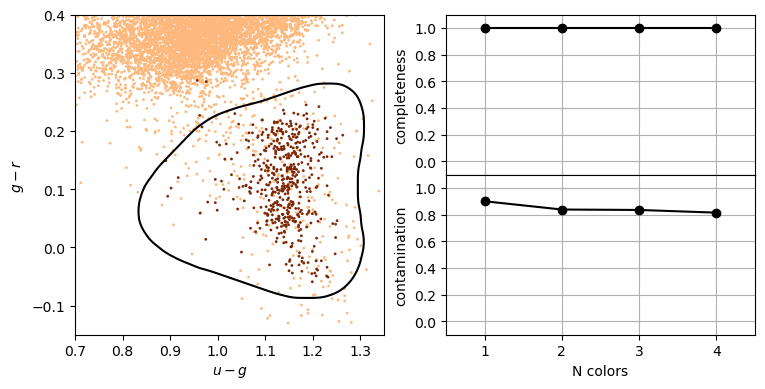

In [20]:
# SVM takes several minutes to run, and is order[N^2]
#  truncating the dataset can be useful for experimentation.
#X_tr = X[::5]
#y_tr = y[::5]


#----------------------------------------------------------------------
# Fit Kernel SVM
Ncolors = np.arange(1, X.shape[1] + 1)

def compute_SVM(Ncolors):
    classifiers = []
    predictions = []

    for nc in Ncolors:
        # perform support vector classification
        clf = SVC(kernel='rbf', gamma=20.0, class_weight='balanced')
        ## THIS IS KEY CALL: data are in X_train and we are using 
        ## the first nc measurements (out of 4 possible, nc <= 4)
        clf.fit(X_train[:, :nc], y_train)
        y_pred = clf.predict(X_test[:, :nc])

        classifiers.append(clf)
        predictions.append(y_pred)

    return classifiers, predictions

classifiers, predictions = compute_SVM(Ncolors)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

#------------------------------------------------------------
# compute the decision boundary
clf = classifiers[1]
xlim = (0.7, 1.35)
ylim = (-0.15, 0.4)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 101),
                     np.linspace(ylim[0], ylim[1], 101))

Z = clf.predict(np.c_[yy.ravel(), xx.ravel()])
Z = Z.reshape(xx.shape)

# smooth the boundary
from scipy.ndimage import gaussian_filter
Z = gaussian_filter(Z, 2)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(8, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

ax.contour(xx, yy, Z, [0.5], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

# plot completeness vs Ncolors
ax = fig.add_subplot(222)
ax.plot(Ncolors, completeness, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination, 'o-k', ms=6)

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

## Gaussian Naive Bayes <a id='GNBsg'></a>
[Go to top](#toc)

In Gaussian naive Bayes $p_k(x^i)$ are modeled as one-dimensional normal distributions, with means $\mu^i_k$ and widths $\sigma^i_k$. The naive Bayes estimator is then

$$\hat{y} = \arg\max_{y_k}\left[\ln \pi_k - \frac{1}{2}\sum_{i=1}^N\left(2\pi(\sigma^i_k)^2 + \frac{(x^i - \mu^i_k)^2}{(\sigma^i_k)^2} \right) \right]$$

<b> Note: this is the log of the Bayes criterion with no normalization constant </b>

This classifier is easy to implement and very robust. However, it works well only when the distributions are aligned with coordinate axes (that is, when "measurement types" are quite unrelated to each other, such as brightness and size in this example). For a deeper discussion of this problem, see [this paper on star-galaxy separation](http://faculty.washington.edu/ivezic/Publications/Slater_2020_AJ_159_65.pdf). 

We have a 2-dimensional data set (say, x and y) and for each data point we have a binary label L ("star" or "galaxy"). We want to find a line in y-x diagram that optimally separates (that is, that minimizes loss function) the two classes. 

In [21]:
from astroML.datasets import fetch_imaging_sample

def get_stars_and_galaxies(Nstars=10000, Ngals=10000):
    """Get the subset of star/galaxy data to plot"""
    data = fetch_imaging_sample()

    objtype = data['type']

    stars = data[objtype == 6][:Nstars]
    
    galaxies = data[objtype == 3][:Ngals]

    return np.concatenate([stars,galaxies]), np.concatenate([np.zeros(len(stars)), np.ones(len(galaxies))])

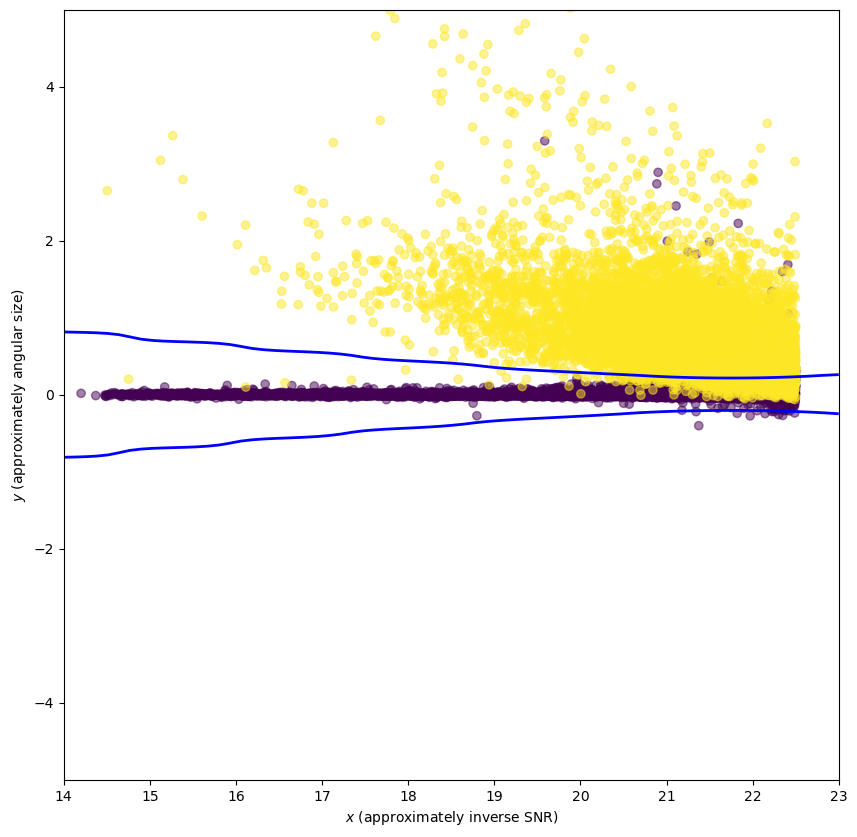

In [22]:
data, y = get_stars_and_galaxies(Nstars=10000, Ngals=10000)

# select r model mag and psf - model mag as columns
X = np.column_stack((data['rRaw'], data['rRawPSF'] - data['rRaw']))

#------------------------------------------------------------
# Fit the Naive Bayes classifier
clf = GaussianNB()
clf.fit(X, y)

# predict the classification probabilities on a grid
xlim = (14, 23)
ylim = (-5, 5)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 71),
                     np.linspace(ylim[0], ylim[1], 81))
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z[:, 1].reshape(xx.shape)

#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
ax.scatter(X[:, 0], X[:, 1], c=y, zorder=2, alpha=0.5)

ax.contour(xx, yy, Z, [0.5], linewidths=2., colors='blue')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$x$ (approximately inverse SNR)')
ax.set_ylabel('$y$ (approximately angular size)')

plt.show()

### Here is a generalization of Gaussian Naive Bayes Classifier to Gaussian Mixture Bayes Classifier

#### The distributions do not have to be aligned with coordinate axes!  (that is, we allow for non-vanishing covariances between the measured variables).

In [23]:
from sklearn.mixture import GaussianMixture

class GMMBayes(GaussianNB):
    """GaussianMixture Bayes Classifier

    This is a generalization to the Naive Bayes classifier: rather than
    modeling the distribution of each class with axis-aligned gaussians,
    GMMBayes models the distribution of each class with mixtures of
    gaussians.  This can lead to better classification in some cases.

    Parameters
    ----------
    n_components : int or list
        number of components to use in the GaussianMixture. If specified as
        a list, it must match the number of class labels. Default is 1.
    **kwargs : dict, optional
        other keywords are passed directly to GaussianMixture
    """

    def __init__(self, n_components=1, **kwargs):
        self.n_components = np.atleast_1d(n_components)
        self.kwargs = kwargs

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape

        if n_samples != y.shape[0]:
            raise ValueError("X and y have incompatible shapes")

        self.classes_ = np.unique(y)
        self.classes_.sort()
        unique_y = self.classes_

        n_classes = unique_y.shape[0]

        if self.n_components.size not in (1, len(unique_y)):
            raise ValueError("n_components must be compatible with "
                             "the number of classes")

        self.gmms_ = [None for i in range(n_classes)]
        self.class_prior_ = np.zeros(n_classes)

        n_comp = np.zeros(len(self.classes_), dtype=int) + self.n_components

        for i, y_i in enumerate(unique_y):
            if n_comp[i] > X[y == y_i].shape[0]:
                warnstr = ("Expected n_samples >= n_components but got "
                           "n_samples={0}, n_components={1}, "
                           "n_components set to {0}.")
                warnings.warn(warnstr.format(X[y == y_i].shape[0], n_comp[i]))
                n_comp[i] = y_i
            self.gmms_[i] = GaussianMixture(n_comp[i], **self.kwargs).fit(X[y == y_i])
            self.class_prior_[i] = np.float(np.sum(y == y_i)) / n_samples

        return self

    def _joint_log_likelihood(self, X):

        X = np.asarray(np.atleast_2d(X))
        logprobs = np.array([g.score_samples(X) for g in self.gmms_]).T
        return logprobs + np.log(self.class_prior_)

## Comparison of many methods using ROC curves <a id='roc'></a>
[Go to top](#toc)
 

In [24]:
#----------------------------------------------------------------------
# get data and split into training & testing sets
X, y = fetch_rrlyrae_combined()
X = X[:, [1, 0, 2, 3]]  # rearrange columns for better 1-color results
(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)

N_tot = len(y)
N_st = np.sum(y == 0)
N_rr = N_tot - N_st
N_train = len(y_train)
N_test = len(y_test)
N_plot = 5000 + N_rr

GaussianNB
LinearDiscriminantAnalysis
QuadraticDiscriminantAnalysis
LogisticRegression
KNeighborsClassifier
DecisionTreeClassifier
GMMBayes


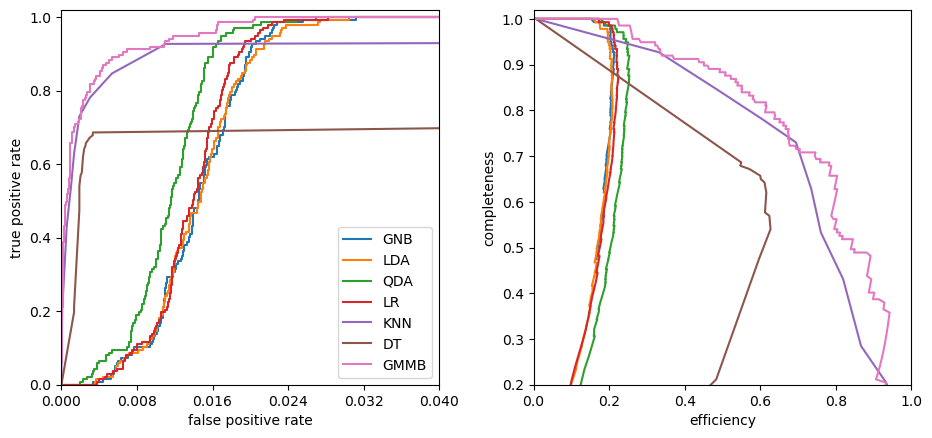

In [25]:
# This monkey-patch takes care of older astronomy packages that have not yet been updated for NumPy 2.x.
np.float = float


#------------------------------------------------------------
# Fit all the models to the training data
def compute_models(*args):
    names = []
    probs = []
    for classifier, kwargs in args:
        print(classifier.__name__)
        clf = classifier(**kwargs)
        clf.fit(X_train, y_train)
        y_probs = clf.predict_proba(X_test)[:, 1]

        names.append(classifier.__name__)
        probs.append(y_probs)

    return names, probs


names, probs = compute_models((GaussianNB, {}),
                              (LinearDiscriminantAnalysis, {}),
                              (QuadraticDiscriminantAnalysis, {}),
                              (LogisticRegression,
                               dict(class_weight='balanced')),
                              (KNeighborsClassifier,
                               dict(n_neighbors=10)),
                              (DecisionTreeClassifier,
                               dict(random_state=0, max_depth=12,
                                    criterion='entropy')),
                              (GMMBayes, dict(n_components=3, tol=1E-5, covariance_type='full'))
                              )

#------------------------------------------------------------
# Plot ROC curves and completeness/efficiency
fig = plt.figure(figsize=(10, 5))
fig.subplots_adjust(left=0.1, right=0.95, bottom=0.15, top=0.9, wspace=0.25)


# ax2 will show roc curves
ax1 = plt.subplot(121)

# ax1 will show completeness/efficiency
ax2 = plt.subplot(122)

labels = dict(GaussianNB='GNB',
              LinearDiscriminantAnalysis='LDA',
              QuadraticDiscriminantAnalysis='QDA',
              KNeighborsClassifier='KNN',
              DecisionTreeClassifier='DT',
              GMMBayes='GMMB',
              LogisticRegression='LR')

thresholds = np.linspace(0, 1, 1001)[:-1]

# iterate through and show results
for name, y_prob in zip(names, probs):
    fpr, tpr, thresh = roc_curve(y_test, y_prob)

    # add (0, 0) as first point
    fpr = np.concatenate([[0], fpr])
    tpr = np.concatenate([[0], tpr])

    ax1.plot(fpr, tpr, label=labels[name])

    comp = np.zeros_like(thresholds)
    cont = np.zeros_like(thresholds)
    for i, t in enumerate(thresholds):
        y_pred = (y_prob >= t)
        comp[i], cont[i] = completeness_contamination(y_pred, y_test)
    ax2.plot(1 - cont, comp, label=labels[name])

ax1.set_xlim(0, 0.04)
ax1.set_ylim(0, 1.02)
ax1.xaxis.set_major_locator(plt.MaxNLocator(5))
ax1.set_xlabel('false positive rate')
ax1.set_ylabel('true positive rate')
ax1.legend(loc=4)

ax2.set_xlabel('efficiency')
ax2.set_ylabel('completeness')
ax2.set_xlim(0, 1.0)
ax2.set_ylim(0.2, 1.02)

plt.show()

### which method is the best in this case? 


### Let's now say a few more words about these classification methods: what exactly do they do? 


## Linear and quadratic discriminant analysis

Linear discriminant analysis (LDA) assumes  the class distributions have identical
covariances for all $k$ classes (all classes are a set of shifted Gaussians). The
optimal classifier is derived from the log of the class
posteriors 

$$g_k(\vec{x}) = \vec{x}^T \Sigma^{-1} \vec{\mu_k} - \frac{1}{2}\vec{\mu_k}^T \Sigma^{-1} \vec{\mu_k} + \log \pi_k,
$$

with $\vec{\mu_k}$ the mean of class $k$ and $\Sigma$ the covariance of the
Gaussians. The class dependent covariances that would normally give rise to a quadratic dependence on
$\vec{x}$ cancel out if they are assumed to be constant. The Bayes classifier is, therefore, linear with respect to $\vec{x}$.

The discriminant boundary between classes is the line that minimizes
the overlap between Gaussians

$$  g_k(\vec{x}) - g_\ell(\vec{x}) = \vec{x}^T \Sigma^{-1} (\mu_k-\mu_\ell)  - \frac{1}{2}(\mu_k - \mu_\ell)^T \Sigma^{-1}(\mu_k -\mu_\ell)  + \log (\frac{\pi_k}{\pi_\ell}) = 0. $$



Relaxing the requirement that the covariances of the
Gaussians are constant, the discriminant function
becomes quadratic in $x$:

$$ g(\vec{x}) = -\frac{1}{2} \log | \Sigma_k |   - \frac{1}{2}(\vec{x}-\mu_k)^T C^{-1}(\vec{x}-\mu_k) + \log \pi_k. $$

This is sometimes known as _quadratic discriminant analysis_ (QDA)

In [26]:
#----------------------------------------------------------------------
# perform LinearDiscriminantAnalysis
classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)

for nc in Ncolors:
    clf = LinearDiscriminantAnalysis()
    clf.fit(X_train[:, :nc], y_train)
    y_pred = clf.predict(X_test[:, :nc])

    classifiers.append(clf)
    predictions.append(y_pred)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness [0.48175182 0.67153285 0.67153285 0.67153285]
contamination [0.85300668 0.80590717 0.80467091 0.80590717]


In [27]:
# perform QuadraticDiscriminantAnalysis
qclassifiers = []
qpredictions = []

for nc in Ncolors:
    qlf = QuadraticDiscriminantAnalysis()
    qlf.fit(X_train[:, :nc], y_train)
    qy_pred = qlf.predict(X_test[:, :nc])

    qclassifiers.append(qlf)
    qpredictions.append(qy_pred)

qpredictions = np.array(qpredictions)

qcompleteness, qcontamination = completeness_contamination(qpredictions, y_test)

print("completeness", qcompleteness)
print("contamination", qcontamination)

completeness [0.48175182 0.68613139 0.73722628 0.78832117]
contamination [0.85201794 0.79249448 0.77555556 0.75675676]


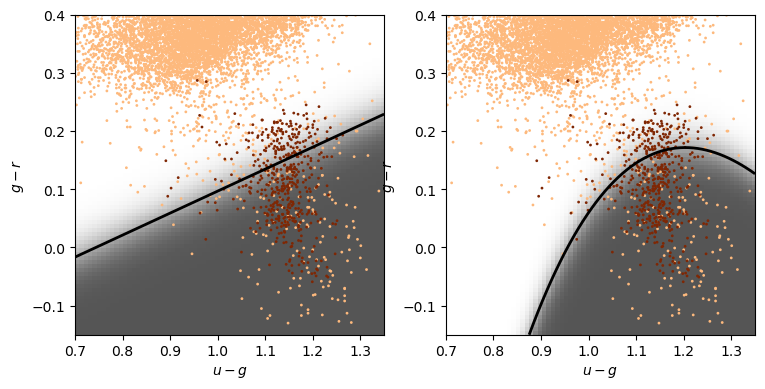

In [28]:
#------------------------------------------------------------
# Compute the decision boundary
clf = classifiers[1]
qlf = qclassifiers[1]

xlim = (0.7, 1.35)
ylim = (-0.15, 0.4)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 71),
                     np.linspace(ylim[0], ylim[1], 81))


Z = clf.predict_proba(np.c_[yy.ravel(), xx.ravel()])
Z = Z[:, 1].reshape(xx.shape)

QZ = qlf.predict_proba(np.c_[yy.ravel(), xx.ravel()])
QZ = QZ[:, 1].reshape(xx.shape)



#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(8, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z, origin='lower', aspect='auto',
               cmap=plt.cm.binary, zorder=1,
               extent=xlim + ylim)
im.set_clim(0, 1.5)

ax.contour(xx, yy, Z, [0.5], linewidths=2., colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

# right plot: qda
ax = fig.add_subplot(122)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(QZ, origin='lower', aspect='auto',
               cmap=plt.cm.binary, zorder=1,
               extent=xlim + ylim)
im.set_clim(0, 1.5)

ax.contour(xx, yy, QZ, [0.5], linewidths=2., colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')


plt.show()

## GMM and Bayes classification

The natural extension to the Gaussian assumptions is to use GMM's to learn the density distribution. 

The number of Gaussian components $K$ must be chosen for each class independently


completeness [[0.48175182 0.68613139 0.73722628 0.78832117]
 [0.         0.11678832 0.41605839 0.68613139]]
contamination [[0.85201794 0.79249448 0.77605322 0.75675676]
 [0.         0.33333333 0.13636364 0.21666667]]


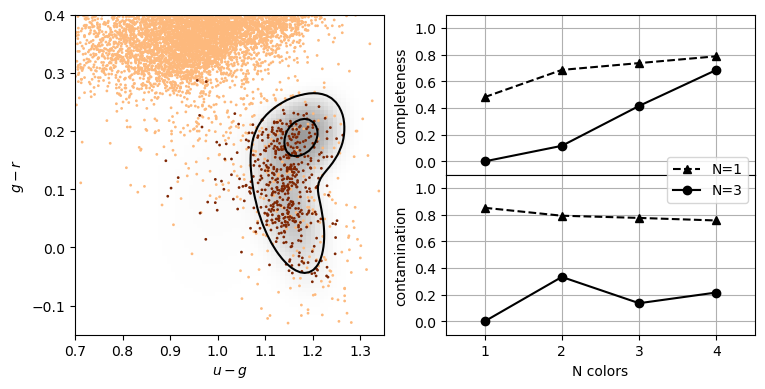

In [29]:
# GMM-bayes takes several minutes to run, and is order[N^2]
# where N is the sample size
#  truncating the dataset can be useful for experimentation.
#X_tr = X[::10]
#y_tr = y[::10]

np.float = float

#----------------------------------------------------------------------
# perform GMM Bayes
Ncolors = np.arange(1, X.shape[1] + 1)
Ncomp = [1, 3]


def compute_GMMbayes(Ncolors, Ncomp):
    classifiers = []
    predictions = []

    for ncm in Ncomp:
        classifiers.append([])
        predictions.append([])
        for nc in Ncolors:
            clf = GMMBayes(ncm, tol=1E-5, covariance_type='full')
            clf.fit(X_train[:, :nc], y_train)
            y_pred = clf.predict(X_test[:, :nc])

            classifiers[-1].append(clf)
            predictions[-1].append(y_pred)

    return classifiers, predictions

classifiers, predictions = compute_GMMbayes(Ncolors, Ncomp)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

#------------------------------------------------------------
# Compute the decision boundary
clf = classifiers[1][1]
xlim = (0.7, 1.35)
ylim = (-0.15, 0.4)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 71),
                     np.linspace(ylim[0], ylim[1], 81))

Z = clf.predict_proba(np.c_[yy.ravel(), xx.ravel()])
Z = Z[:, 1].reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(8, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z, origin='lower', aspect='auto',
               cmap=plt.cm.binary, zorder=1,
               extent=xlim + ylim)
im.set_clim(0, 1.5)

ax.contour(xx, yy, Z, [0.1], colors='k')
ax.contour(xx, yy, Z, [0.5], colors='k')
ax.contour(xx, yy, Z, [0.9], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

# plot completeness vs Ncolors
ax = fig.add_subplot(222)
ax.plot(Ncolors, completeness[0], '^--k', ms=6, label='N=%i' % Ncomp[0])
ax.plot(Ncolors, completeness[1], 'o-k', ms=6, label='N=%i' % Ncomp[1])

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination[0], '^--k', ms=6, label='N=%i' % Ncomp[0])
ax.plot(Ncolors, contamination[1], 'o-k', ms=6, label='N=%i' % Ncomp[1])
ax.legend(loc='lower right',
          bbox_to_anchor=(1.0, 0.78))

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))

ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

You can see that 1-component classifier is pretty bad, while with 
3 components, the performance significantly improves.

## K-nearest neighbours

As with density estimation (and kernel density estimation)  the intuitive justification is that $p(y|x) \approx p(y|x')$ if $x'$ is very close to $x$.  

The number of neighbors, $K$, regulates the complexity of the classification. In simplest form, a majority rule classification is adopted, where each of the $K$ points votes on the classification. Increasing $K$ decreases the variance in the classification but at the expense of an increase in the bias.  

Weights can be assigned to  individual votes by weighting the vote by the distance to the nearest point.

completeness [[0.1459854  0.3649635  0.46715328 0.54014599]
 [0.00729927 0.24087591 0.40145985 0.53284672]]
contamination [[0.82758621 0.52830189 0.44347826 0.41732283]
 [0.83333333 0.44067797 0.24657534 0.23958333]]


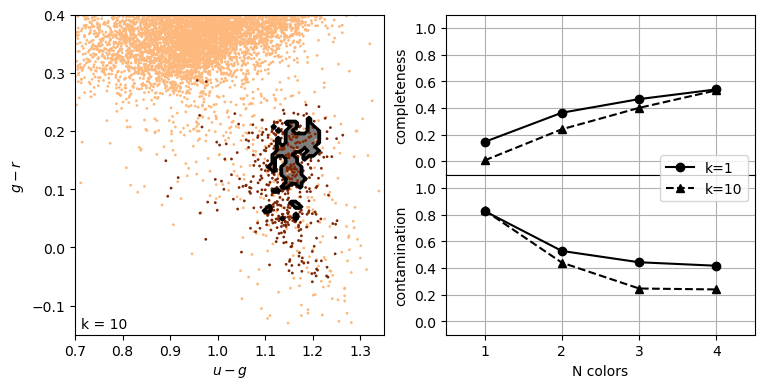

In [30]:
#----------------------------------------------------------------------
# perform Classification

classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)
kvals = [1, 10]

for k in kvals:
    classifiers.append([])
    predictions.append([])
    for nc in Ncolors:
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(X_train[:, :nc], y_train)
        y_pred = clf.predict(X_test[:, :nc])

        classifiers[-1].append(clf)
        predictions[-1].append(y_pred)

completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

#------------------------------------------------------------
# Compute the decision boundary
clf = classifiers[1][1]
xlim = (0.7, 1.35)
ylim = (-0.15, 0.4)

xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 71),
                     np.linspace(ylim[0], ylim[1], 81))

Z = clf.predict(np.c_[yy.ravel(), xx.ravel()])
Z = Z.reshape(xx.shape)

#----------------------------------------------------------------------
# plot the results
fig = plt.figure(figsize=(8, 4))
fig.subplots_adjust(bottom=0.15, top=0.95, hspace=0.0,
                    left=0.1, right=0.95, wspace=0.2)

# left plot: data and decision boundary
ax = fig.add_subplot(121)
im = ax.scatter(X[-N_plot:, 1], X[-N_plot:, 0], c=y[-N_plot:],
                s=4, lw=0, cmap=plt.cm.Oranges, zorder=2)
im.set_clim(-0.5, 1)

im = ax.imshow(Z, origin='lower', aspect='auto',
               cmap=plt.cm.binary, zorder=1,
               extent=xlim + ylim)
im.set_clim(0, 2)

ax.contour(xx, yy, Z, [0.5], colors='k')
ax.contour(xx, yy, Z, [0.9], colors='k')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_xlabel('$u-g$')
ax.set_ylabel('$g-r$')

ax.text(0.02, 0.02, "k = %i" % kvals[1],
        transform=ax.transAxes)

# plot completeness vs Ncolors
ax = fig.add_subplot(222)

ax.plot(Ncolors, completeness[0], 'o-k', ms=6, label='k=%i' % kvals[0])
ax.plot(Ncolors, completeness[1], '^--k', ms=6, label='k=%i' % kvals[1])

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.NullFormatter())

ax.set_ylabel('completeness')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

# plot contamination vs Ncolors
ax = fig.add_subplot(224)
ax.plot(Ncolors, contamination[0], 'o-k', ms=6, label='k=%i' % kvals[0])
ax.plot(Ncolors, contamination[1], '^--k', ms=6, label='k=%i' % kvals[1])
ax.legend(loc='lower right',
          bbox_to_anchor=(1.0, 0.79))

ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%i'))
ax.set_xlabel('N colors')
ax.set_ylabel('contamination')
ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.1, 1.1)
ax.grid(True)

plt.show()

## for completeness, SVM on a multi-dimensional dataset

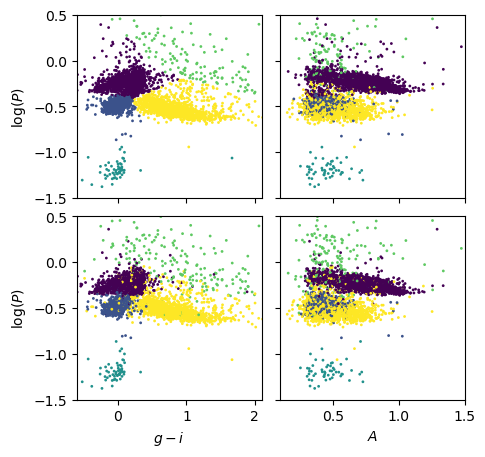

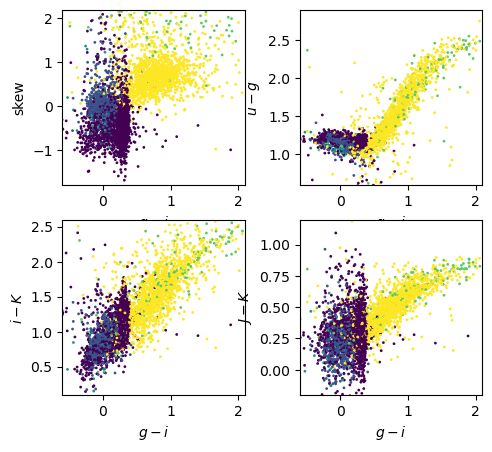

In [31]:
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
from __future__ import print_function

import numpy as np
from matplotlib import pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from astroML.datasets import fetch_LINEAR_geneva

#----------------------------------------------------------------------
data = fetch_LINEAR_geneva()

# classification is done twice: 2-dim case and 7-dim case
attributes = [('gi', 'logP'),
              ('gi', 'logP', 'ug', 'iK', 'JK', 'Ampl', 'skew')]
labels = ['$u-g$', '$g-i$', '$i-K$', '$J-K$',
          r'$\log(P)$', 'amplitude', 'skew']
cls = 'LCtype'
Ntrain = 3000

#------------------------------------------------------------
# Create attribute arrays
X = []
y = []

for attr in attributes:
    X.append(np.vstack([data[a] for a in attr]).T)
    LCtype = data[cls].copy()

    # there is no #3.  For a better color scheme in plots,
    # we'll set 6->3
    LCtype[LCtype == 6] = 3
    y.append(LCtype)


#@pickle_results('LINEAR_SVM.pkl')
def compute_SVM_results(i_train, i_test):
    classifiers = []
    predictions = []
    Xtests = []
    ytests = []
    Xtrains = []
    ytrains = []

    for i in range(len(attributes)):
        Xtrain = X[i][i_train]
        Xtest = X[i][i_test]
        ytrain = y[i][i_train]
        ytest = y[i][i_test]

        clf = SVC(kernel='linear', class_weight=None)
        clf.fit(Xtrain, ytrain)
        y_pred = clf.predict(Xtest)

        classifiers.append(clf)
        predictions.append(y_pred)

    return classifiers, predictions


i = np.arange(len(data))
i_train, i_test = train_test_split(i, random_state=0, train_size=2000)
clfs, ypred = compute_SVM_results(i_train, i_test)


#------------------------------------------------------------
# Plot the results
fig = plt.figure(figsize=(5, 5))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

class_labels = []

for i in range(2):
    Xtest = X[i][i_test]
    ytest = y[i][i_test]
    amp = data['Ampl'][i_test]

    # Plot the resulting classifications
    ax1 = fig.add_subplot(221 + 2 * i)
    ax1.scatter(Xtest[:, 0], Xtest[:, 1],
                c=ypred[i], edgecolors='none', s=4, linewidths=0)

    ax1.set_ylabel(r'$\log(P)$')

    ax2 = plt.subplot(222 + 2 * i)
    ax2.scatter(amp, Xtest[:, 1],
                c=ypred[i], edgecolors='none', s=4, lw=0)

    #------------------------------
    # set axis limits
    ax1.set_xlim(-0.6, 2.1)
    ax2.set_xlim(0.1, 1.5)
    ax1.set_ylim(-1.5, 0.5)
    ax2.set_ylim(-1.5, 0.5)

    ax2.yaxis.set_major_formatter(plt.NullFormatter())
    if i == 0:
        ax1.xaxis.set_major_formatter(plt.NullFormatter())
        ax2.xaxis.set_major_formatter(plt.NullFormatter())
    else:
        ax1.set_xlabel(r'$g-i$')
        ax2.set_xlabel(r'$A$')

#------------------------------------------------------------
# Second figure
fig = plt.figure(figsize=(5, 5))
fig.subplots_adjust(left=0.11, right=0.95, wspace=0.3)

attrs = ['skew', 'ug', 'iK', 'JK']
labels = ['skew', '$u-g$', '$i-K$', '$J-K$']
ylims = [(-1.8, 2.2), (0.6, 2.9), (0.1, 2.6), (-0.2, 1.2)]

for i in range(4):
    ax = fig.add_subplot(221 + i)
    ax.scatter(data['gi'][i_test], data[attrs[i]][i_test],
               c=ypred[1], edgecolors='none', s=4, lw=0)
    ax.set_xlabel('$g-i$')
    ax.set_ylabel(labels[i])

    ax.set_xlim(-0.6, 2.1)
    ax.set_ylim(ylims[i])

plt.show() 

# ...and now you will (may?) shine...

### here is a way for you to nail "participation in class: 10%" 

Below I read a catalog of objects that have morphological classification (from the HST COSMOS field that have optical photometry (colors).
In particular, 5 colors are listed: ug, gr, ri, iz and zy, and magnitude (rmag). For each 
objects we have a flag that tells us if that source in unresolved by HST and thus likely a star (starFlag).

Your task is to use **which ever supervised classification method** above you think would work and 
develop a 5-dimensional color-based classifier to find stars. Limit the sample to 16 < rmag < 25. 
Measure and plot the ROC curve for stellar subsample (sample of true stars with starFlag=True).

Compare the performance for rmag<24 vs. 24 < rmag < 25.

Compare the performance when only objects with flag detect_isIsolated set to True.

For **"extra credit":**
- if you are, like, super motivated, do many methods and compare their ROC performance  (❤️)

Bring your work to Thursday class (you can send me your ipynb file before the class) and show 
to us all what you did (in 3-5 mins, depending on how many people do it). 

**Hint**: beware of NaN's in the catalog

In [50]:
import pandas as pd
data = pd.read_parquet('SGcolorSeparation.parquet')
# separate into stars and galaxies 
stars = data[data['starFlag'] == True]
gals = data[data['starFlag'] == False] 

In [51]:
stars

,coord_ra,coord_dec,detect_isIsolated,starFlag,rmag,ug,gr,ri,iz,zy,Ar
37808,149.616890,1.490800,True,True,26.342058,NaN,1.088295,0.504580,0.282602,NaN,0.053454
37818,149.679755,1.491392,True,True,26.735077,0.828093,-0.002842,0.552561,-0.159981,NaN,0.056878
37819,149.596275,1.491685,True,True,26.584732,NaN,0.937853,0.702732,-0.325180,NaN,0.052716
37824,149.614360,1.492952,True,True,25.921127,-0.199137,-0.098543,0.019541,-0.044809,-0.035919,0.053403
37833,149.677766,1.494574,True,True,25.573719,3.859644,0.431519,0.033974,0.116432,NaN,0.056865
...,...,...,...,...,...,...,...,...,...,...,...
865258,149.579890,2.974761,False,True,25.505077,0.010365,0.076191,-0.200125,-0.340424,1.183987,0.055409
865270,149.568390,2.974363,False,True,25.315266,0.797754,0.429241,-0.008257,0.172194,-0.511978,0.055857
865273,149.568726,2.973588,False,True,26.190893,0.340754,1.129274,0.829678,0.941078,0.177223,0.055819
865275,149.557679,2.974914,False,True,28.124638,-0.669197,-1.380466,0.920660,0.831732,1.379631,0.056289


(-0.5, 2.5)

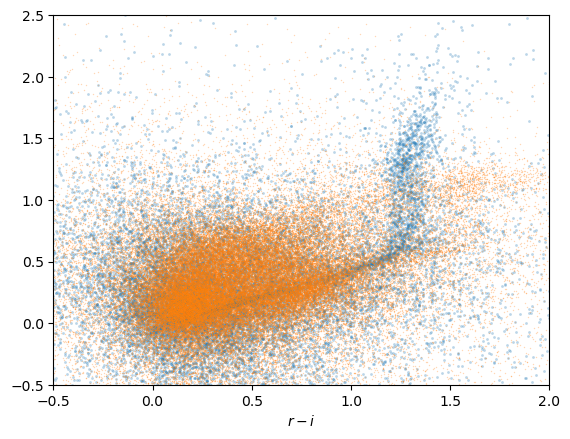

In [52]:
plt.plot(stars['gr'], stars['ri'], 'o', ms=2, alpha=0.3, mew=0)
plt.plot(gals['gr'], gals['ri'], '.', ms=2, alpha=0.3, mew=0)

plt.xlabel(r'$g-r$')
plt.xlabel(r'$r-i$')
plt.xlim(-0.5, 2.0)
plt.ylim(-0.5, 2.5)

(-0.2, 1.1)

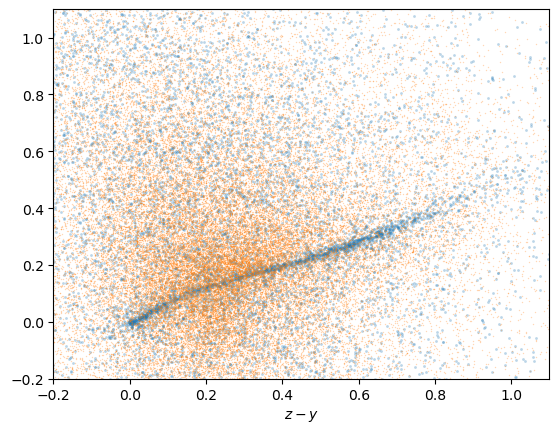

In [53]:
plt.plot(stars['iz'], stars['zy'], 'o', ms=2, alpha=0.3, mew=0)
plt.plot(gals['iz'], gals['zy'], '.', ms=2, alpha=0.3, mew=0)

plt.xlabel(r'$r-i$')
plt.xlabel(r'$z-y$')
plt.xlim(-0.2, 1.1)
plt.ylim(-0.2, 1.1)